# 3.2 The Electric Potential and Electrostatic Energy

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume III — Classical Electrodynamics",
    number="3.2",
    title="The Electric Potential and Electrostatic Energy",
    blurb="From field to potential: the work done moving a charge, why that "
    "work is path-independent, equipotential surfaces, and the energy "
    "stored in an arrangement of charges and in the field itself.",
    difficulty="intermediate",
    estimate="90–120 min",
)

<ECP header: 2541 chars of HTML>

## Notebook overview

[§3.1](coulomb-field.ipynb) built the electric field. This one trades it for a scalar. Because
the electrostatic field is **conservative**, the work it does on a test charge
depends only on the endpoints, and that fact lets us summarise the entire vector
field by a single number at each point: the **potential** $V$. A scalar is easier
to compute, easier to plot, and easier to superpose, and most of electrostatics is
more naturally phrased through it. The field is never lost, only repackaged: we
recover it at any moment as $\mathbf E = -\nabla V$.

We develop the work-and-energy side of electrostatics and, with it, two pieces of
numerical vector calculus the rest of the volume needs: the **numerical gradient**
(to get $\mathbf E$ back from $V$) and **numerical line and volume integration**
(to compute work, potentials of distributions, and stored energy). Each is
introduced where the physics first calls for it. We confirm path-independence
directly, watch equipotentials and field lines form an orthogonal mesh, assemble
a few charges and count their energy two different ways, and locate that energy in
the field itself through $u = \tfrac{\varepsilon_0}{2}|\mathbf E|^2$. The notebook
closes on the idea that drives the rest of the volume: a conductor is an
equipotential, and finding the potential subject to fixed conductor values is the
**boundary-value problem** that [§3.4](laplace-poisson.ipynb) solves on a grid.

Everything is in **SI units**, with $\varepsilon_0 = 8.854\times10^{-12}\,$F/m and
$k = 1/4\pi\varepsilon_0 \approx 8.99\times10^9$. The objects here, potential maps
and equipotentials, are static by nature, so this notebook has no animations: a
contour plot shows a scalar field better than motion could.

> **How to read the checks.** Each exercise ends with a `validate` call against an
> independent fact: $-\nabla V$ matching the Coulomb field, a closed-loop integral
> vanishing, two energy bookkeepings agreeing. A ✓ is strong evidence; a ✗ is a
> prompt to *locate the discrepancy*, not a verdict.

> **Scope.** A working review, not a full electrodynamics course. The standard
> references are Nolting, *Theoretical Physics 3* {cite}`nolting3`, and Griffiths,
> *Introduction to Electrodynamics* {cite}`griffiths_em` (ch. 2).

## Theory in brief

### The potential as work per charge

Moving a test charge through the field requires work, and because the
electrostatic field is conservative that work depends only on the endpoints. This
defines the **potential** as the work per unit charge to bring a charge in from
infinity,

```{math}
:label: eq-potential-def
V(\mathbf r) = -\int_{\infty}^{\mathbf r} \mathbf E\cdot d\boldsymbol\ell ,
```

a scalar measured in volts. For a single point charge the integral gives

```{math}
:label: eq-V-point
V(\mathbf r) = \frac{1}{4\pi\varepsilon_0}\,\frac{q}{r} .
```

### Field from potential

Inverting the definition, the field is the (negative) gradient of the potential,

```{math}
:label: eq-E-gradV
\mathbf E = -\nabla V ,
```

so $\mathbf E$ points "downhill" in $V$ and its magnitude is the steepness. We
compute $\nabla$ numerically with central differences (the same stencils as
[§0.3](../00-foundations/quadrature-differentiation.ipynb)), which is why a
dense grid matters.

### Path-independence and conservative fields

That a potential exists *at all* is the statement that the field is conservative:
the work around any closed loop vanishes, equivalently the curl is zero,

```{math}
:label: eq-path
\oint \mathbf E\cdot d\boldsymbol\ell = 0
\quad\Longleftrightarrow\quad \nabla\times\mathbf E = 0 .
```

This holds throughout electrostatics; Griffiths {cite}`griffiths_em` (ch. 2)
derives both statements from Coulomb's law. It fails once a changing magnetic field
induces an electric field (Faraday's law, [§3.7](induction.ipynb)), where
$\nabla\times\mathbf E \ne 0$ and no single-valued potential exists.

### Equipotential surfaces and the potential of a distribution

Surfaces of constant $V$ are **equipotentials**. Since $\mathbf E = -\nabla V$ is
normal to the level sets of $V$, the field is everywhere perpendicular to them, and
field lines and equipotentials form an orthogonal mesh. For an extended source we
superpose, and because $V$ is a scalar this is often easier than summing the field:

```{math}
:label: eq-V-dist
V(\mathbf r) = \frac{1}{4\pi\varepsilon_0}\int
\frac{\rho(\mathbf r')}{|\mathbf r - \mathbf r'|}\,d^3r' .
```

### Electrostatic energy

The work to assemble a set of charges, brought in one by one from infinity, is

```{math}
:label: eq-es-energy
W = \frac{1}{2}\sum_i q_i\,V(\mathbf r_i)
  = \sum_{i<j} \frac{1}{4\pi\varepsilon_0}\frac{q_i q_j}{r_{ij}} ,
```

where the factor $\tfrac12$ in the first form removes the double counting of each
pair, and the second form is the sum over distinct pairs. The same energy can be
pictured as living in the field, with energy density

```{math}
:label: eq-energy-density
u = \frac{\varepsilon_0}{2}\,|\mathbf E|^2,
\qquad W = \frac{\varepsilon_0}{2}\int |\mathbf E|^2\,d^3r .
```

These are two views of one quantity; Griffiths {cite}`griffiths_em` (ch. 2)
carries the rearrangement from the charge sum to the field integral out in full.
The field view is the one that survives into radiation, where energy detaches
from the charges and travels on its own.

## Setup

Data and instruments: the SI constants of the volume ($\varepsilon_0$, $k$, the
nanocoulomb charge scale, the two charge colours), and the closed-form Coulomb
field of [§3.1](coulomb-field.ipynb) restated here as the *independent
reference* that every numerical gradient in the notebook is checked against.
The potential itself is not here: you write `V_point` in Exercise 1, its
superposition `V_field` in Exercise 3, and the line-integral machinery of the
work theorem in Exercise 2.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

from ecp import draw, validate

# SI constants, shared across Volume III.
from scipy.constants import epsilon_0 as EPS0  # data: vacuum permittivity, F/m

K = 1.0 / (4.0 * np.pi * EPS0)  # data: Coulomb constant ≈ 8.99e9 N·m²/C²
NANO = 1e-9  # data: 1 nC
POS, NEG = "#c1121f", "#16213e"  # data: positive charge red, negative dark blue


# built from scratch in §3.1 (Exercise 1); restated here as an instrument —
# the independent reference that −∇V is measured against. Recovering this
# field from the potential is the lesson; writing it out again is not.
def E_point(q, r0, X, Y):
    """In-plane components of a point-charge field (the Coulomb field of §3.1).

    Parameters
    ----------
    q : float
        Charge in coulombs.
    r0 : tuple of float
        Source position ``(x0, y0)``.
    X, Y : numpy.ndarray
        Field-point grids.

    Returns
    -------
    Ex, Ey : numpy.ndarray
        The two in-plane field components, in V/m.
    """
    dx, dy = X - r0[0], Y - r0[1]
    d = np.sqrt(dx**2 + dy**2)
    with np.errstate(divide="ignore", invalid="ignore"):
        return K * q * dx / d**3, K * q * dy / d**3


# built from scratch in §3.1 (Exercise 2); restated here as an instrument —
# the vector counterpart of the `V_field` you build in Exercise 3, kept here
# because it too is only ever the yardstick the gradient is compared with.
def E_field(charges, X, Y):
    """Total field of several point charges by superposition.

    Parameters
    ----------
    charges : list of tuple
        Each ``(q, (x0, y0))``.
    X, Y : numpy.ndarray
        Field-point grids.

    Returns
    -------
    Ex, Ey : numpy.ndarray
        The summed in-plane field components, in V/m.
    """
    Ex = np.zeros(np.shape(X), float)
    Ey = np.zeros(np.shape(Y), float)
    for q, r0 in charges:
        ex, ey = E_point(q, r0, X, Y)
        Ex, Ey = Ex + ex, Ey + ey
    return Ex, Ey

## Exercise 1 — Potential of a point charge, and E = −∇V

We start with the scalar that stands behind the
field. The point-charge potential of {eq}`eq-V-point` is a smooth hill, and the
field of [§3.1](coulomb-field.ipynb) is its (downhill) gradient, {eq}`eq-E-gradV`.
Recovering one from the other numerically introduces the **numerical gradient**:
`numpy.gradient` applies central differences on the grid (the stencils of
[§0.3](../00-foundations/quadrature-differentiation.ipynb)), so a dense grid
keeps the truncation error small. The charge here is $q = 1\,$nC at the origin,
where $V$ diverges; the singular value is left as `inf`/`nan` for the caller to
mask rather than patched inside the potential itself.

1. Write `V_point(q, r0, X, Y)`, the potential $V = kq/r$ of
   {eq}`eq-V-point` for a charge $q$ sitting at $\mathbf r_0 = (x_0, y_0)$,
   evaluated on the field-point grids `X`, `Y`.
   **Write this one yourself** — the implementation is the lesson.
2. On a $400\times400$ grid over $[-0.5, 0.5]^2\,$m (which does not sample
   the singular point itself), evaluate $V$ with it, then take
   its gradient with `numpy.gradient` (passing the axis coordinates so the
   spacing is correct) and form $\mathbf E = -\nabla V$.
3. Compare it to the closed-form Coulomb field of [§3.1](coulomb-field.ipynb)
   on the region
   $0.15 < r < 0.45\,$m (away from the singularity and the one-sided grid
   edges), confirming the recovery to a relative error well below $10^{-3}$
   ({numref}`fig-pot-point`).

In [3]:
# (solution hidden on the public site)


E = −∇V vs Coulomb field on 0.15<r<0.45 m: max relative error = 2.73e-04


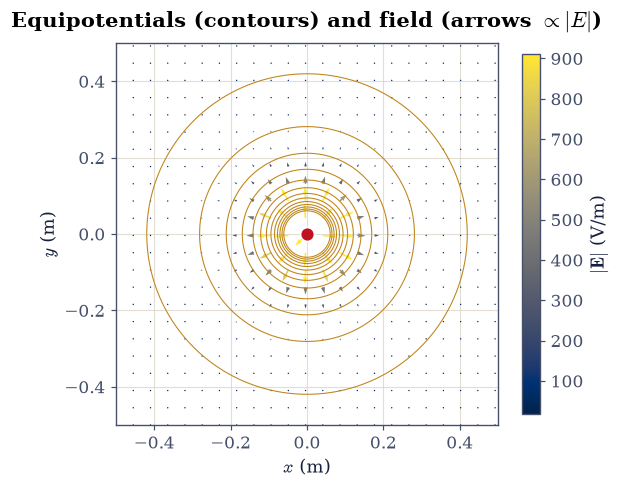

In [4]:
# (solution hidden on the public site)


### Validation 1

In [5]:
validate.close(max_rel_E, 0.0, "E = −∇V recovers the Coulomb field", atol=1e-3)

✓  E = −∇V recovers the Coulomb field   [got 0.000273226 vs expected 0 (rtol=1e-06, atol=0.001)]


True

## Exercise 2 — Path-independence

The reason a potential exists is that the work is
**path-independent**: {eq}`eq-path` says the line integral of $\mathbf E$ between
two points does not depend on the route, only on the endpoints, and equals
$-(V_B - V_A)$. We test this directly by integrating along different paths and
comparing. Each path is parametrised by $t\in[0,1]$, and the scalar integrand
$\mathbf E(\mathbf r(t))\cdot\mathbf r'(t)$ is integrated with
`scipy.integrate.quad` (adaptive, default tolerances). The charge is again
$q = 1\,$nC at the origin.

1. Write `line_integral(path, dpath)`, the work per unit charge
   $\int_0^1 \mathbf E(\mathbf r(t))\cdot\mathbf r'(t)\,dt$ along a path
   handed over as two callables, `path(t) -> (x, y)` and its velocity
   `dpath(t) -> (dx/dt, dy/dt)` on $t\in[0,1]$, evaluated with
   `scipy.integrate.quad`.
   **Write this one yourself** — the implementation is the lesson.
2. Take $A=(0.3, 0)$ and $B=(0, 0.3)\,$m (the same radius) and integrate
   $\int\mathbf E\cdot d\boldsymbol\ell$ with it along
   the straight segment $A\to B$ and along the circular arc of radius
   $0.3\,$m from $A$ to $B$; both give zero, since $A$ and $B$ share a
   potential.
3. For endpoints at *different* radii, $P=(0.3, 0)$ and $Q=(0, 0.5)\,$m,
   integrate along the straight segment and along the two-leg polyline
   $P\to(0.3, 0.5)\to Q$, and confirm both equal $-(V_Q - V_P)\ne 0$.

This path-independence is exactly what lets a potential exist; it will fail
once induction enters ([§3.7](induction.ipynb)).

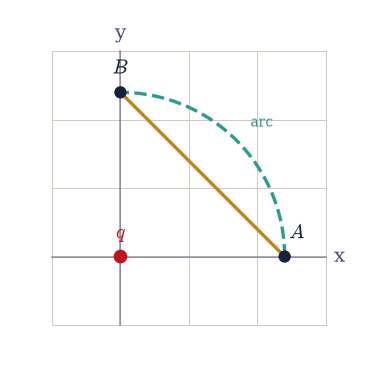

In [6]:
# (solution hidden on the public site)


In [7]:
# (solution hidden on the public site)


(a) A,B same radius:  straight = -4.99e-16,  arc = -2.98e-16,  −ΔV = -0.00e+00
(b) P,Q diff radii:   straight = 1.1983e+01,  polyline = 1.1983e+01,  −ΔV = 1.1983e+01


### Validation 2

In [8]:
validate.close(
    work_straight_AB,
    -(Vpt(B) - Vpt(A)),
    "the work equals −ΔV (here zero) on the straight path",
    atol=1e-15,
)
validate.close(
    work_arc_AB, 0.0, "the arc at fixed radius does no work (E ⊥ dℓ)", atol=1e-12
)
validate.close(
    work_straight_PQ,
    work_poly_PQ,
    "two different paths give the same work (path-independence)",
    rtol=1e-6,
)
validate.close(
    work_straight_PQ, minus_dV, "and that common work equals −(V_Q − V_P)", rtol=1e-6
)

✓  the work equals −ΔV (here zero) on the straight path   [got -4.99357e-16 vs expected -0 (rtol=1e-06, atol=1e-15)]
✓  the arc at fixed radius does no work (E ⊥ dℓ)   [got -2.97924e-16 vs expected 0 (rtol=1e-06, atol=1e-12)]
✓  two different paths give the same work (path-independence)   [got 11.9834 vs expected 11.9834 (rtol=1e-06, atol=1e-09)]
✓  and that common work equals −(V_Q − V_P)   [got 11.9834 vs expected 11.9834 (rtol=1e-06, atol=1e-09)]


True

## Exercise 3 — Equipotentials are perpendicular to the field

Because $\mathbf E = -\nabla V$ ({eq}`eq-E-gradV`), the
field points straight across the level sets of $V$: equipotentials and field lines
meet at right angles. We check this without relying on magnitudes by measuring the
alignment of the analytic field with $-\nabla V$ (their cosine should be $1$), then
draw the orthogonal mesh. The pair here is $+1\,$nC at $(-0.15, 0)$ and
$-1\,$nC at $(+0.15, 0)\,$m, and it needs the extended-source form of the
potential, {eq}`eq-V-dist`, which for point sources is just a sum.

1. Write `V_field(charges, X, Y)`, the total potential of a list of
   `(q, (x0, y0))` charges: superpose the `V_point` contributions you wrote
   in Exercise 1. Superposing a scalar is the whole advantage of the
   potential, and this one-line sum is what it comes to.
2. Evaluate $V$ with it on a $400\times400$ grid over $[-0.5, 0.5]^2\,$m, take
   $-\nabla V$ with `numpy.gradient`, and compute the cosine between it and
   the analytic superposed field on $0.08 < r < 0.45\,$m from both charges.
3. Confirm the alignment is $1$ to within $10^{-3}$, then plot equipotentials
   and field lines together ({numref}`fig-pot-orthogonal`).

In [9]:
# (solution hidden on the public site)


min cosine between −∇V and the analytic field = 1.000000  (1 ⇒ E ∥ −∇V ⊥ equipotentials)


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


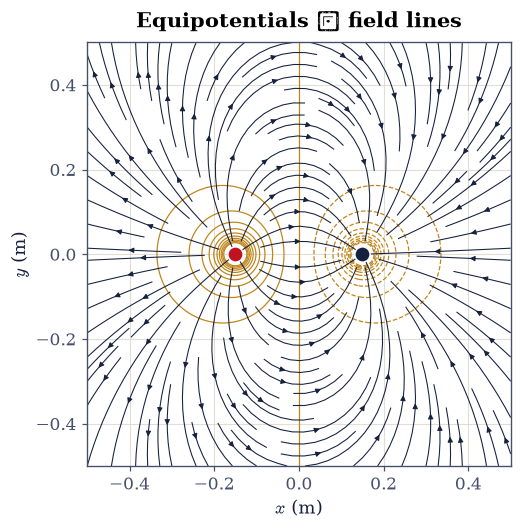

In [10]:
# (solution hidden on the public site)


### Validation 3

In [11]:
validate.close(
    min_cos, 1.0, "E is perpendicular to equipotentials (E ∥ −∇V)", atol=1e-3
)

✓  E is perpendicular to equipotentials (E ∥ −∇V)   [got 1 vs expected 1 (rtol=1e-06, atol=0.001)]


True

## Exercise 4 — Potential of a continuous distribution

A scalar superposes more easily than a vector, so the
potential of an extended source is often the gentler integral, {eq}`eq-V-dist`.
The uniformly charged ring is the clean case: its on-axis potential has a tidy
closed form, and differentiating it returns the on-axis field of
[§3.1](coulomb-field.ipynb). The ring here has radius $R = 0.05\,$m and
carries $Q = 1\,$nC in the $z=0$ plane.

1. Compute the on-axis potential $V(z)$ by integrating {eq}`eq-V-dist` over
   the azimuthal angle with `numpy.trapezoid` on a dense grid of $720$
   points, and confirm it equals $kQ/\sqrt{z^2+R^2}$.
2. Sample $V(z)$ on a $z$-grid, take $E_z = -dV/dz$ with `numpy.gradient`,
   and confirm it matches the ring field $kQz/(z^2+R^2)^{3/2}$ of
   [§3.1](coulomb-field.ipynb).

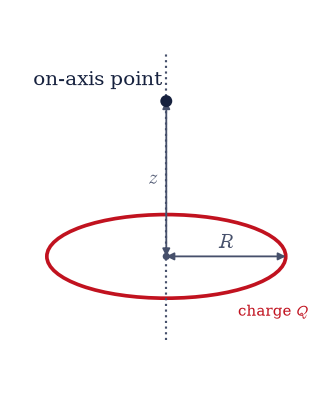

In [12]:
# (solution hidden on the public site)


In [13]:
# (solution hidden on the public site)


ring potential vs kQ/√(z²+R²): max rel error = 4.44e-16
E_z = −dV/dz vs the §3.1 ring field: max rel error (interior) = 8.70e-04


### Validation 4

In [14]:
validate.close(
    V_num, V_closed, "the ring's on-axis potential is kQ/√(z²+R²)", rtol=1e-4
)
validate.close(
    max_rel_Ez, 0.0, "E_z = −dV/dz recovers the ring field of §3.1", atol=1e-2
)

✓  the ring's on-axis potential is kQ/√(z²+R²)   [max|Δ| = 5.68434e-14 (rtol=0.0001, atol=1e-09)]
✓  E_z = −dV/dz recovers the ring field of §3.1   [got 0.000869659 vs expected 0 (rtol=1e-06, atol=0.01)]


True

## Exercise 5 — Energy of an assembly of charges

Bringing charges together from infinity costs work,
and that stored work is the **electrostatic energy** {eq}`eq-es-energy`. There are
two equivalent bookkeepings: half the sum of each charge times the potential of all
the others, or the sum over distinct pairs. The factor $\tfrac12$ in the first form
is exactly what stops every pair being counted twice. The assembly here is
three charges, $q = +1, +2, -1\,$nC at $(0,0)$, $(0.1, 0)$, and
$(0, 0.1)\,$m, whose energy is worth computing both ways.

1. Compute it directly as $\tfrac12\sum_i q_i V(\mathbf r_i)$, each
   $V(\mathbf r_i)$ summing the other two charges' point potentials.
2. Compute it again as the pairwise sum $\sum_{i<j} kq_iq_j/r_{ij}$.
3. Confirm the two agree.

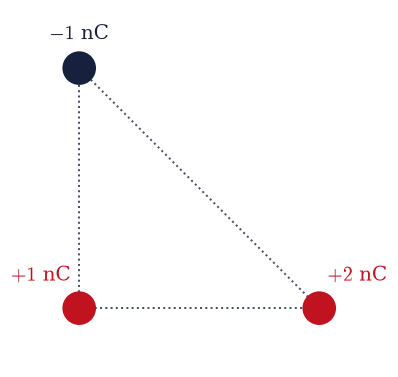

In [15]:
# (solution hidden on the public site)


In [16]:
# (solution hidden on the public site)


½ Σ qᵢVᵢ   = -3.7228e-08 J
Σ pairs    = -3.7228e-08 J


### Validation 5

In [17]:
validate.close(
    half_sum_qV,
    pair_sum,
    "the assembly energy ½ΣqᵢVᵢ equals the pairwise sum",
    rtol=1e-10,
)

✓  the assembly energy ½ΣqᵢVᵢ equals the pairwise sum   [got -3.72277e-08 vs expected -3.72277e-08 (rtol=1e-10, atol=1e-09)]


True

## Exercise 6 — Energy stored in the field (student exercise)

The same energy can be located not in the charges
but in the **field**, with density $u = \tfrac{\varepsilon_0}{2}|\mathbf E|^2$
({eq}`eq-energy-density`). Integrating that density over all space must give back
the assembly energy, and this is the view that survives into radiation, where the
energy leaves the charges behind. The uniformly charged sphere is the clean test:
its field is known inside and out, and the total energy has the closed form
$W = \tfrac{3}{5}\,kQ^2/R$. For a sphere of radius $R = 0.05\,$m carrying
$Q = 1\,$nC spread uniformly through its volume, that field is
$E(r) = kQr/R^3$ inside ($r<R$) and $kQ/r^2$ outside.

1. Compute $W = \tfrac{\varepsilon_0}{2}\int|\mathbf E|^2\,d^3r$ by
   integrating in spherical coordinates with `numpy.trapezoid` over
   $(r,\theta,\varphi)$. Because the integrand is spherically symmetric the
   angular integrals factor out (to $2$ and $2\pi$), so use a radial grid
   that is dense near $R$ and extends far enough that the $1/r^4$ tail is
   negligible.
2. Compare to $\tfrac{3}{5}\,kQ^2/R$.

Because the check tests the *energy*, a ✗ means "re-examine the field or the
integration grid," never a plotting issue.

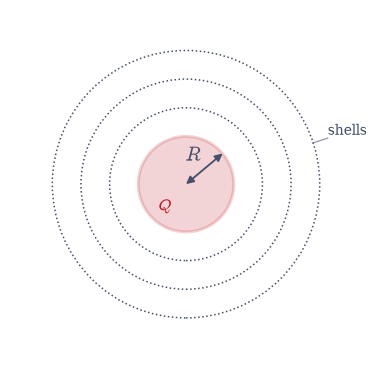

In [18]:
# (solution hidden on the public site)


In [19]:
# (solution hidden on the public site)


field-energy integral (ε₀/2)∫|E|²dV = 1.0777e-07 J
closed form (3/5)kQ²/R              = 1.0785e-07 J
relative difference                 = 7.59e-04


### Validation 6

In [20]:
validate.close(
    W_field,
    W_closed,
    "the field-energy integral (ε₀/2)∫|E|²dV matches (3/5)kQ²/R",
    rtol=1e-2,
)

✓  the field-energy integral (ε₀/2)∫|E|²dV matches (3/5)kQ²/R   [got 1.07769e-07 vs expected 1.07851e-07 (rtol=0.01, atol=1e-09)]


True

## Exercise 7 — The potential map of a dipole

The dipole of [§3.1](coulomb-field.ipynb) looks even simpler through its
potential: a positive hill over $+q$ and a negative well over $-q$, with the
field crossing the equipotentials at right angles as always. Recovering the field
from this map is one more use of the numerical gradient. The dipole here is
$+1\,$nC at $(0, +0.01)$ and $-1\,$nC at $(0, -0.01)\,$m.

1. Evaluate $V$ on the $400\times400$ grid with the `V_field` you wrote in
   Exercise 3, and plot its $+/-$ lobes as
   equipotential contours ({numref}`fig-pot-dipole`).
2. Confirm that $-\nabla V$ (via `numpy.gradient`) reproduces the analytic
   dipole field of [§3.1](coulomb-field.ipynb) on $0.04 < r < 0.45\,$m from
   each charge.

In [21]:
# (solution hidden on the public site)


dipole field recovered from −∇V: max relative error = 6.58e-03


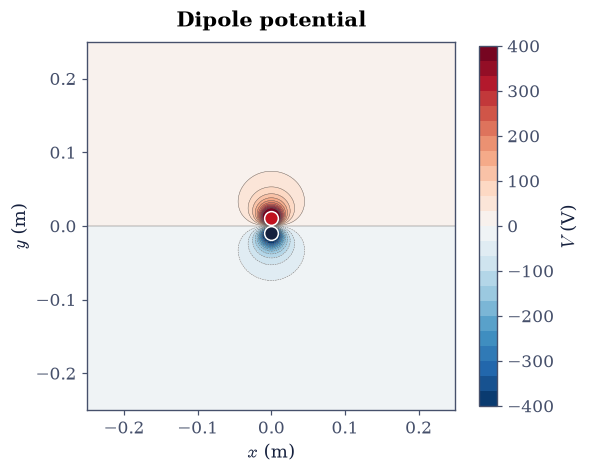

In [22]:
# (solution hidden on the public site)


### Validation 7

In [23]:
validate.close(
    max_rel_dip, 0.0, "the dipole field is recovered from its potential", atol=1e-2
)

✓  the dipole field is recovered from its potential   [got 0.00657884 vs expected 0 (rtol=1e-06, atol=0.01)]


True

## Exercise 8 — The conductor as an equipotential (synthesis, forward to 3.4)

A theme to close on, and the gateway to the rest of
the volume. In electrostatic equilibrium a conductor is an **equipotential
volume**: charges rearrange until $\mathbf E = 0$ inside (any interior field would
push them further), which makes $V$ constant throughout and $\mathbf E$ normal at
the surface. The practical question then inverts. Instead of being handed the
charges and finding $V$, we are handed the conductor potentials and must find $V$
everywhere between them. That is the **boundary-value problem** at the heart of
[§3.4](laplace-poisson.ipynb), where Laplace's equation $\nabla^2 V = 0$ is
solved on a grid.

Here we solve the simplest case in closed form and confirm it numerically. For two
concentric spherical conductors, inner radius $a = 0.05\,$m held at $V_a = 100\,$V
and outer radius $b = 0.15\,$m held at $V_b = 0$, spherical symmetry reduces
Laplace's equation to $\tfrac{d}{dr}\!\big(r^2\,dV/dr\big) = 0$, whose solution is
$V(r) = A + B/r$, linear in $1/r$.

1. Build the finite-difference form of $\tfrac{d}{dr}(r^2\,dV/dr)=0$ on a
   radial grid over $[a,b]$ with Dirichlet values at the ends, assemble the
   tridiagonal system, and solve it with `numpy.linalg.solve` (a small dense
   solve here; [§3.4](laplace-poisson.ipynb) graduates to the sparse 2-D
   version). **Write this one yourself** — the implementation is the lesson.
2. Confirm the numerical $V(r)$ matches the closed form $A + B/r$ fixed by
   the two boundary values.

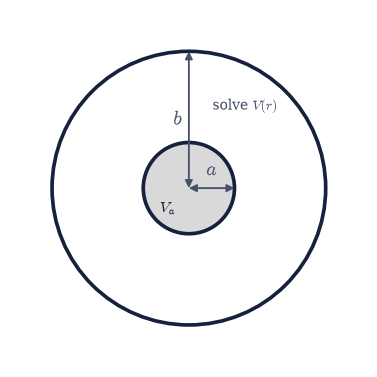

In [24]:
# (solution hidden on the public site)


In [25]:
# (solution hidden on the public site)


concentric-sphere BVP: numeric vs closed-form A+B/r, max rel error = 9.34e-06
  (A = -50.000 V, B = 7.5000 V·m)


### Validation 8

In [26]:
validate.close(
    V_numeric,
    V_exact,
    "the finite-difference BVP solve reproduces the closed-form V(r)=A+B/r",
    rtol=1e-3,
)

✓  the finite-difference BVP solve reproduces the closed-form V(r)=A+B/r   [max|Δ| = 0.000282484 (rtol=0.001, atol=1e-09)]


True

## Notebook summary

- The scalar potential $V=kq/r$ and $\mathbf E=-\nabla V$, recovered against the Coulomb
  field to a relative error $\sim10^{-3}$ (`numpy.gradient`).
- Path-independence: the work $\int\mathbf E\cdot d\boldsymbol\ell$ matched $-\Delta V$ on
  two different paths (`scipy.integrate.quad`), and equipotentials met field lines at right
  angles (minimum cosine $\approx1$).
- The charged ring's potential $kQ/\sqrt{z^2+R^2}$ with $-dV/dz$ recovering the
  [§3.1](coulomb-field.ipynb) field;
  the assembly energy $\tfrac12\sum_i q_iV_i$ equal to the pairwise sum; the field energy
  $\int(\varepsilon_0/2)|\mathbf E|^2\,dV=\tfrac35 kQ^2/R$; and the dipole potential map.
- The conductor as an equipotential by finite-difference relaxation, foreshadowing the
  boundary-value problem of [§3.4](laplace-poisson.ipynb).

## Outlook

- **Capacitance and stored energy.** The energy of a capacitor is this assembly
  energy specialised to two conductors; forces follow from the energy method,
  $F = -dW/dx$.
- **The multipole expansion of $V$.** At large $r$ the potential of any bounded
  distribution is a series in $1/r$ (monopole, dipole, quadrupole), taken up in
  [§3.5](multipole-expansion.ipynb); the scalar makes the expansion far cleaner
  than for the field.
- **The self-energy puzzle.** The field-energy integral $\tfrac{\varepsilon_0}{2}
  \int|\mathbf E|^2$ diverges for a true point charge (the $1/r^4$ density near
  $r=0$), a genuine flaw of classical electrodynamics that points toward field
  theory.
- **Earnshaw, again.** In potential language: $\nabla^2 V = 0$ in free space
  forbids a local minimum of $V$, so no charge can sit in stable electrostatic
  equilibrium. This is the same impossibility met in [§3.1](coulomb-field.ipynb),
  and a forward hook to Laplace's equation in [§3.4](laplace-poisson.ipynb).

### References

```{bibliography}
:filter: docname in docnames
```

In [27]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>